<a href="https://colab.research.google.com/github/Calebchike/Volve_Production_EDA/blob/main/Volve_Production_EDA_Q%26A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Module**

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Import File**

**Import Data as df**

In [15]:
file_path = "https://github.com/Calebchike/Volve_Production_EDA/raw/eb69a061765c53a95d1f6d811e9d9c522ae902aa/Volve%20production%20data.xlsx"
df = pd.read_excel(file_path)
df.head(5)

,DATEPRD,WELL_BORE_CODE,NPD_WELL_BORE_CODE,NPD_WELL_BORE_NAME,NPD_FIELD_CODE,NPD_FIELD_NAME,NPD_FACILITY_CODE,NPD_FACILITY_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,...,AVG_CHOKE_UOM,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND,WELL_TYPE
0,2014-04-07,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,0.00000,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,WI
1,2014-04-08,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
2,2014-04-09,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
3,2014-04-10,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,NaN,...,%,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production,OP
4,2014-04-11,NO 15/9-F-1 C,7405,15/9-F-1 C,3420717,VOLVE,369304,MÆRSK INSPIRER,0.0,310.37614,...,%,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production,OP


# **Clean Dataset**

**Duplicate Dataframe and make the date column an index**

In [16]:
volve = df.copy()
volve['DATEPRD'] = pd.to_datetime(volve['DATEPRD'])
volve = volve.set_index('DATEPRD')

**Length of dataframe column before droping columns**

In [17]:
len(volve.columns)

23

**Drop Columns**

In [19]:
columns_to_drop = [
    'WELL_BORE_CODE',
    'NPD_WELL_BORE_CODE',
    'NPD_FIELD_CODE',
    'NPD_FIELD_NAME',
    'NPD_FACILITY_CODE',
    'NPD_FACILITY_NAME',
    'WELL_TYPE',
    'AVG_CHOKE_UOM'
]

volve = volve.drop(columns=columns_to_drop)
volve.head(5)

,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,DP_CHOKE_SIZE,BORE_OIL_VOL,BORE_GAS_VOL,BORE_WAT_VOL,BORE_WI_VOL,FLOW_KIND
DATEPRD,,,,,,,,,,,,,,,
2014-04-07,15/9-F-1 C,0.0,0.00000,0.00000,0.00000,0.0,0.000000,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production
2014-04-08,15/9-F-1 C,0.0,NaN,NaN,NaN,0.0,1.003059,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production
2014-04-09,15/9-F-1 C,0.0,NaN,NaN,NaN,0.0,0.979008,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production
2014-04-10,15/9-F-1 C,0.0,NaN,NaN,NaN,0.0,0.545759,0.00000,0.00000,0.00000,0.0,0.0,0.0,NaN,production
2014-04-11,15/9-F-1 C,0.0,310.37614,96.87589,277.27826,0.0,1.215987,33.09788,10.47992,33.07195,0.0,0.0,0.0,NaN,production


**Length of dataframe column before droping columns**

In [20]:
len(volve.columns)

15

**Percentage of missing data for each column**

In [21]:
missing_data_percentage = (volve.isnull().sum() / len(volve)) * 100
print("Percentage of missing data per column:")
print(missing_data_percentage.sort_values(ascending=False))

Percentage of missing data per column:
BORE_WI_VOL                 63.502622
AVG_ANNULUS_PRESS           49.533069
AVG_CHOKE_SIZE_P            42.951260
AVG_DP_TUBING               42.561085
AVG_DOWNHOLE_TEMPERATURE    42.561085
AVG_DOWNHOLE_PRESSURE       42.561085
AVG_WHT_P                   41.499296
AVG_WHP_P                   41.441730
BORE_GAS_VOL                41.403352
BORE_WAT_VOL                41.403352
BORE_OIL_VOL                41.403352
DP_CHOKE_SIZE                1.880517
ON_STREAM_HRS                1.822950
NPD_WELL_BORE_NAME           0.000000
FLOW_KIND                    0.000000
dtype: float64


**Data type of all the column in the dataset**

In [22]:
print(volve.dtypes)

NPD_WELL_BORE_NAME           object
ON_STREAM_HRS               float64
AVG_DOWNHOLE_PRESSURE       float64
AVG_DOWNHOLE_TEMPERATURE    float64
AVG_DP_TUBING               float64
AVG_ANNULUS_PRESS           float64
AVG_CHOKE_SIZE_P            float64
AVG_WHP_P                   float64
AVG_WHT_P                   float64
DP_CHOKE_SIZE               float64
BORE_OIL_VOL                float64
BORE_GAS_VOL                float64
BORE_WAT_VOL                float64
BORE_WI_VOL                 float64
FLOW_KIND                    object
dtype: object


# **Well Summary**

In [24]:
well_summary_df = volve.copy()

# Fill NaN production and on-stream hours with 0 for accurate summation
well_summary_df['BORE_OIL_VOL'] = well_summary_df['BORE_OIL_VOL'].fillna(0)
well_summary_df['BORE_GAS_VOL'] = well_summary_df['BORE_GAS_VOL'].fillna(0)
well_summary_df['BORE_WAT_VOL'] = well_summary_df['BORE_WAT_VOL'].fillna(0)
well_summary_df['ON_STREAM_HRS'] = well_summary_df['ON_STREAM_HRS'].fillna(0)

# Group by well name and flow kind, then aggregate by some chosen metrics
well_data_summary = well_summary_df.groupby(['NPD_WELL_BORE_NAME', 'FLOW_KIND']).agg(
    Total_Data_Entries=('ON_STREAM_HRS', 'size'), # Count of daily entries for each well
    Total_Oil_Production=('BORE_OIL_VOL', 'sum'),
    Total_Gas_Production=('BORE_GAS_VOL', 'sum'),
    Total_Water_Production=('BORE_WAT_VOL', 'sum'),
    Max_Downhole_Pressure=('AVG_DOWNHOLE_PRESSURE', 'max'),
    Min_Downhole_Pressure=('AVG_DOWNHOLE_PRESSURE', 'min'),
    Max_Wellhead_Pressure=('AVG_WHP_P', 'max'),
    Min_Wellhead_Pressure=('AVG_WHP_P', 'min'),
    Total_On_Stream_Hours=('ON_STREAM_HRS', 'sum')
).reset_index()

# Sort by FLOW_KIND in descending order
well_data_summary = well_data_summary.sort_values(by='FLOW_KIND', ascending=False)

# Add a new column for 'Total On-Stream Days'
well_data_summary['Total_On_Stream_Days'] = well_data_summary['Total_On_Stream_Hours'] / 24

# Display the resulting table
print("Well Production and Pressure Summary:")
well_data_summary

Well Production and Pressure Summary:


,NPD_WELL_BORE_NAME,FLOW_KIND,Total_Data_Entries,Total_Oil_Production,Total_Gas_Production,Total_Water_Production,Max_Downhole_Pressure,Min_Downhole_Pressure,Max_Wellhead_Pressure,Min_Wellhead_Pressure,Total_On_Stream_Hours,Total_On_Stream_Days
0,15/9-F-1 C,production,746,177709.33,2.644092e+07,207302.39,313.87058,0.000000,133.59251,0.0,9983.53315,415.980548
1,15/9-F-11,production,1165,1147849.10,1.743105e+08,1090806.27,317.55131,0.000000,114.70830,0.0,26006.21614,1083.592339
2,15/9-F-12,production,3056,4579609.55,6.675423e+08,6833320.37,317.70115,0.000000,137.31103,0.0,65204.06928,2716.836220
3,15/9-F-14,production,3056,3942233.39,5.780095e+08,7121249.74,334.65614,0.000000,125.71857,0.0,62773.67519,2615.569800
4,15/9-F-15 D,production,978,148518.56,2.250535e+07,52366.40,397.58855,193.187243,118.12727,0.0,17824.83278,742.701366
7,15/9-F-5,production,160,41160.68,6.561826e+06,13533.18,NaN,NaN,83.86524,0.0,2973.32502,123.888543
5,15/9-F-4,injection,3327,0.00,0.000000e+00,0.00,NaN,NaN,NaN,NaN,64267.16117,2677.798382
6,15/9-F-5,injection,3146,0.00,0.000000e+00,0.00,NaN,NaN,NaN,NaN,57856.52806,2410.688669


### Nature of the Wells in the Dataset

Our dataset includes 7 unique well bore names. Based on the `FLOW_KIND` column, these wells can be categorized as follows:

*   **Production-only Wells:** These wells consistently show `FLOW_KIND` as 'production' throughout their observed lifespan. For these wells, we can analyze metrics such as oil production decline and water cut trends. Examples include `15/9-F-1 C`, `15/9-F-11`, `15/9-F-12`, `15/9-F-14`, and `15/9-F-15 D`.

*   **Injection-only Wells:** These wells are primarily used for injecting fluids into the reservoir (e.g., water or gas for pressure support) and do not produce hydrocarbons. `15/9-F-4` falls into this category, showing `FLOW_KIND` as 'injection'. As such, they do not have oil production or water cut data relevant to production analysis.

*   **Dual-Purpose Well (Production and Injection):** The well `15/9-F-5` is unique as it exhibits *both* 'production' and 'injection' `FLOW_KIND` over different periods. This means that at certain times, `15/9-F-5` was used for production, and at other times, it might have been used for injection. This dual nature explains why it was included in the 'production' dataset for water cut analysis (during its production phases) and why its overall production profile might appear intermittent or low.

**Total Production volumn of Gas, Oil and Water**

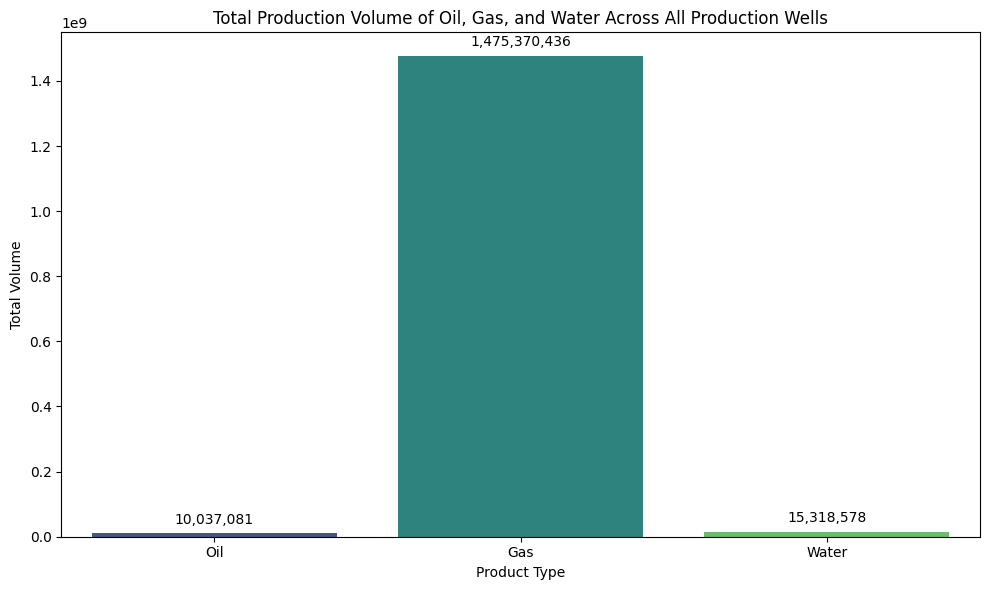

In [29]:
production_wells_summary = well_data_summary[well_data_summary['FLOW_KIND'] == 'production'].copy()

# Calculate the total production for each fluid type across all production wells
total_oil = production_wells_summary['Total_Oil_Production'].sum()
total_gas = production_wells_summary['Total_Gas_Production'].sum()
total_water = production_wells_summary['Total_Water_Production'].sum()

# Create a DataFrame suitable for plotting
total_production_data = pd.DataFrame({
    'Production_Type': ['Oil', 'Gas', 'Water'],
    'Total_Volume': [total_oil, total_gas, total_water]
})

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Production_Type', y='Total_Volume', hue='Production_Type', data=total_production_data, palette='viridis', legend=False)

plt.title('Total Production Volume of Oil, Gas, and Water Across All Production Wells')
plt.xlabel('Product Type')
plt.ylabel('Total Volume')
plt.xticks(rotation=0)
plt.tight_layout()

# Add total volume labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10),
                textcoords='offset points', fontsize=10, color='black')

plt.show()

From the **'Total Production Volume of Oil, Gas, and Water Across All Production Wells'** chart, it is evident that these wells are predominantly **gas producers**. The total gas volume significantly outweighs both oil and water production volumes, indicating that the primary output from these production wells is natural gas.

# **Production Trends & Decline**

## How does oil rate change over each well's life? Where does the decline start?

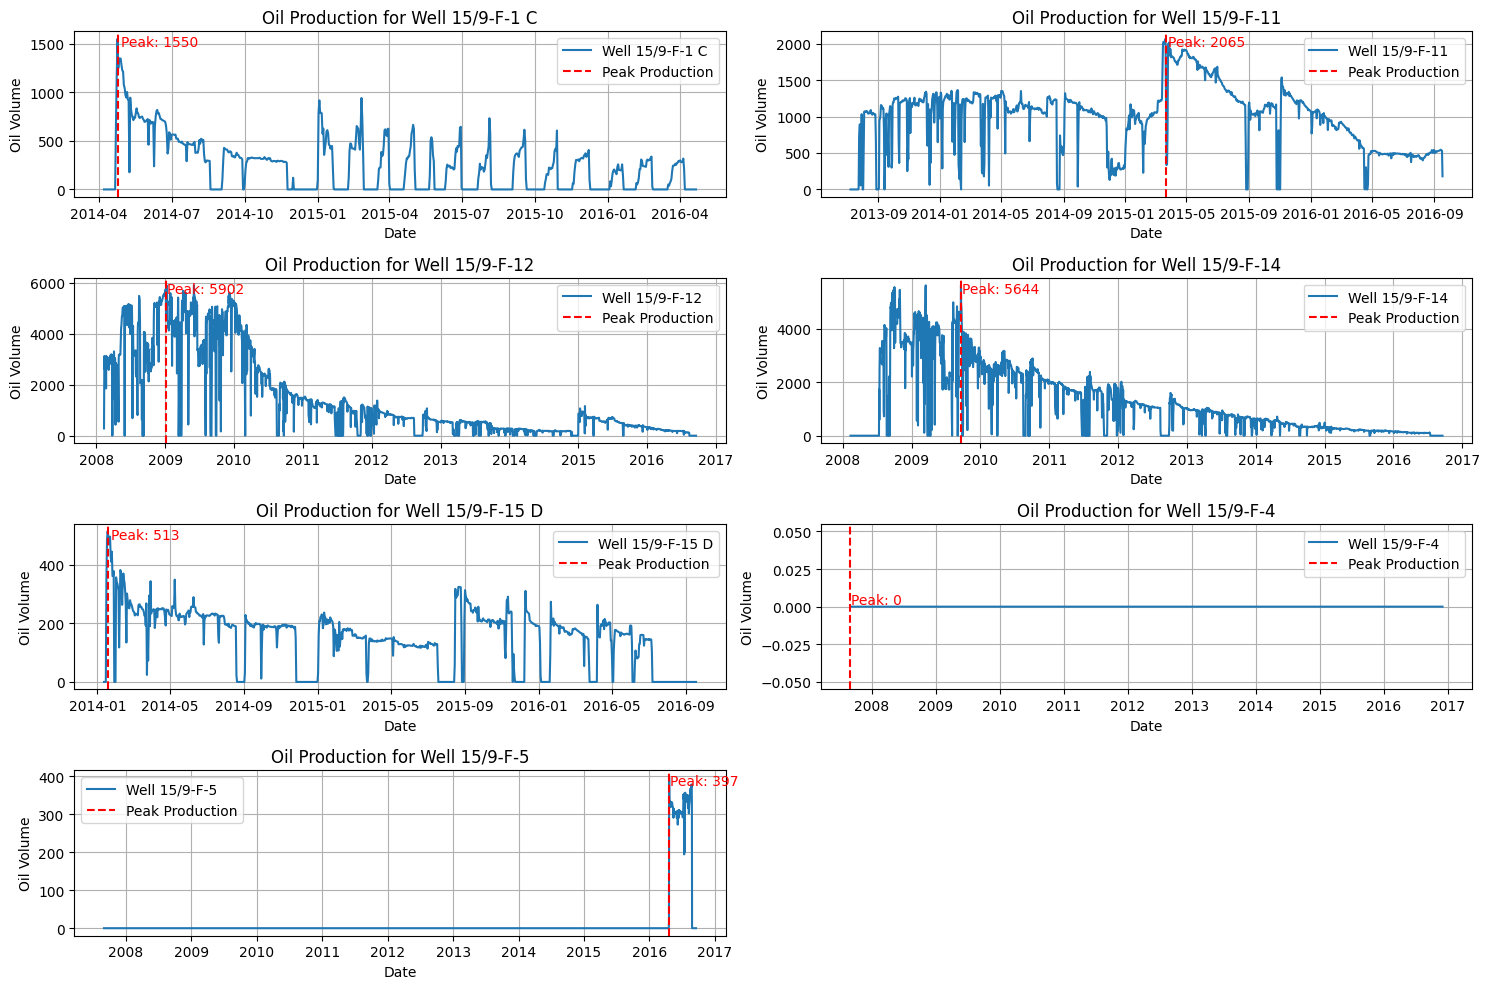

In [25]:
# Group by well and date, then sum the oil volume
well_production = volve.groupby(['NPD_WELL_BORE_NAME', 'DATEPRD'])['BORE_OIL_VOL'].sum().reset_index()

# Get unique well bore codes
well_codes = well_production['NPD_WELL_BORE_NAME'].unique()

plt.figure(figsize=(15, 10))

for i, well in enumerate(well_codes):
    well_data = well_production[well_production['NPD_WELL_BORE_NAME'] == well]

    # Sort by date to ensure correct plotting
    well_data = well_data.sort_values(by='DATEPRD')

    plt.subplot(len(well_codes) // 2 + 1, 2, i + 1)  # Adjust subplot grid as needed
    plt.plot(well_data['DATEPRD'], well_data['BORE_OIL_VOL'], label=f'Well {well}')

    # Find the peak production to indicate decline start
    max_prod_date = well_data.loc[well_data['BORE_OIL_VOL'].idxmax()]['DATEPRD']
    max_prod_value = well_data['BORE_OIL_VOL'].max()

    plt.axvline(x=max_prod_date, color='r', linestyle='--', label='Peak Production')
    plt.text(max_prod_date + pd.Timedelta(days=5), max_prod_value * 0.93, f'Peak: {max_prod_value:.0f}', rotation=0, va='bottom', ha='left', color='red')

    plt.title(f'Oil Production for Well {well}')
    plt.xlabel('Date')
    plt.ylabel('Oil Volume')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

plt.tight_layout()
plt.show()


Upon reviewing the oil production profiles for each well, we can observe varied decline patterns:

- Some wells (e.g., 15/9-F-12, 15/9-F-14) show a relatively **steady and gradual decline** after reaching their peak production. This suggests a more conventional reservoir depletion behavior.

- Other wells (e.g., 15/9-F-1 C, 15/9-F-11, 15/9-F-15 D) exhibit periods of **more pronounced drops or 'stages'**, often followed by flatter periods or even brief increases before continuing to decline. These sharper drops might correlate with operational interventions, changes in choke settings, well issues, or specific reservoir events.

- Well 15/9-F-5 shows a more **intermittent or lower production profile** with less clear decline trends, possibly due to its lower overall production or operational characteristics.

- Well 15/9-F-4, as previously identified, is an injection well and thus shows zero oil production, hence no decline pattern related to oil production.

Overall, the production decline appears to be a mix of both gradual fading and more distinct stages, depending on the individual well's characteristics and operational history.

## Which wells gave the most cumulative oil? Which gave the least, and why?

The well `'15/9-F-4'` has the least oil production (0.00) because it is classified as an **injection well**, not a production well, as observed in the `FLOW_KIND` column. Injection wells are used to inject fluids into the reservoir to maintain pressure or sweep oil towards production wells, not to produce oil themselves. The well `'15/9-F-5'` has very low cumulative oil production, indicating minimal or intermittent oil production during the observed period.

In [26]:
# Create a copy of the main DataFrame to work with all wells
all_wells_df = volve.copy()

# Fill NaN in BORE_OIL_VOL with 0 before calculating cumulative sum for all wells
all_wells_df['BORE_OIL_VOL'] = all_wells_df['BORE_OIL_VOL'].fillna(0)

# Calculate cumulative oil production for each well (including injection wells)
cumulative_oil_all_wells = all_wells_df.groupby('NPD_WELL_BORE_NAME')['BORE_OIL_VOL'].sum().sort_values(ascending=False)

print(f"Number of unique wells (including production and injection): {cumulative_oil_all_wells.nunique()}")
cumulative_oil_all_wells

print("------Wells with the Most Cumulative Oil Production (All Wells)------")
print(f"{cumulative_oil_all_wells.head(5)}")
print("\n")
print("------Wells with the Least Cumulative Oil Production (All Wells)------")
print(f"{cumulative_oil_all_wells.tail(2)}")

Number of unique wells (including production and injection): 7
------Wells with the Most Cumulative Oil Production (All Wells)------
NPD_WELL_BORE_NAME
15/9-F-12      4579609.55
15/9-F-14      3942233.39
15/9-F-11      1147849.10
15/9-F-1 C      177709.33
15/9-F-15 D     148518.56
Name: BORE_OIL_VOL, dtype: float64


------Wells with the Least Cumulative Oil Production (All Wells)------
NPD_WELL_BORE_NAME
15/9-F-5    41160.68
15/9-F-4        0.00
Name: BORE_OIL_VOL, dtype: float64


# **Water & Gas Behavior**

## When does water cut climb for each well? Is the climb the same shape across wells?

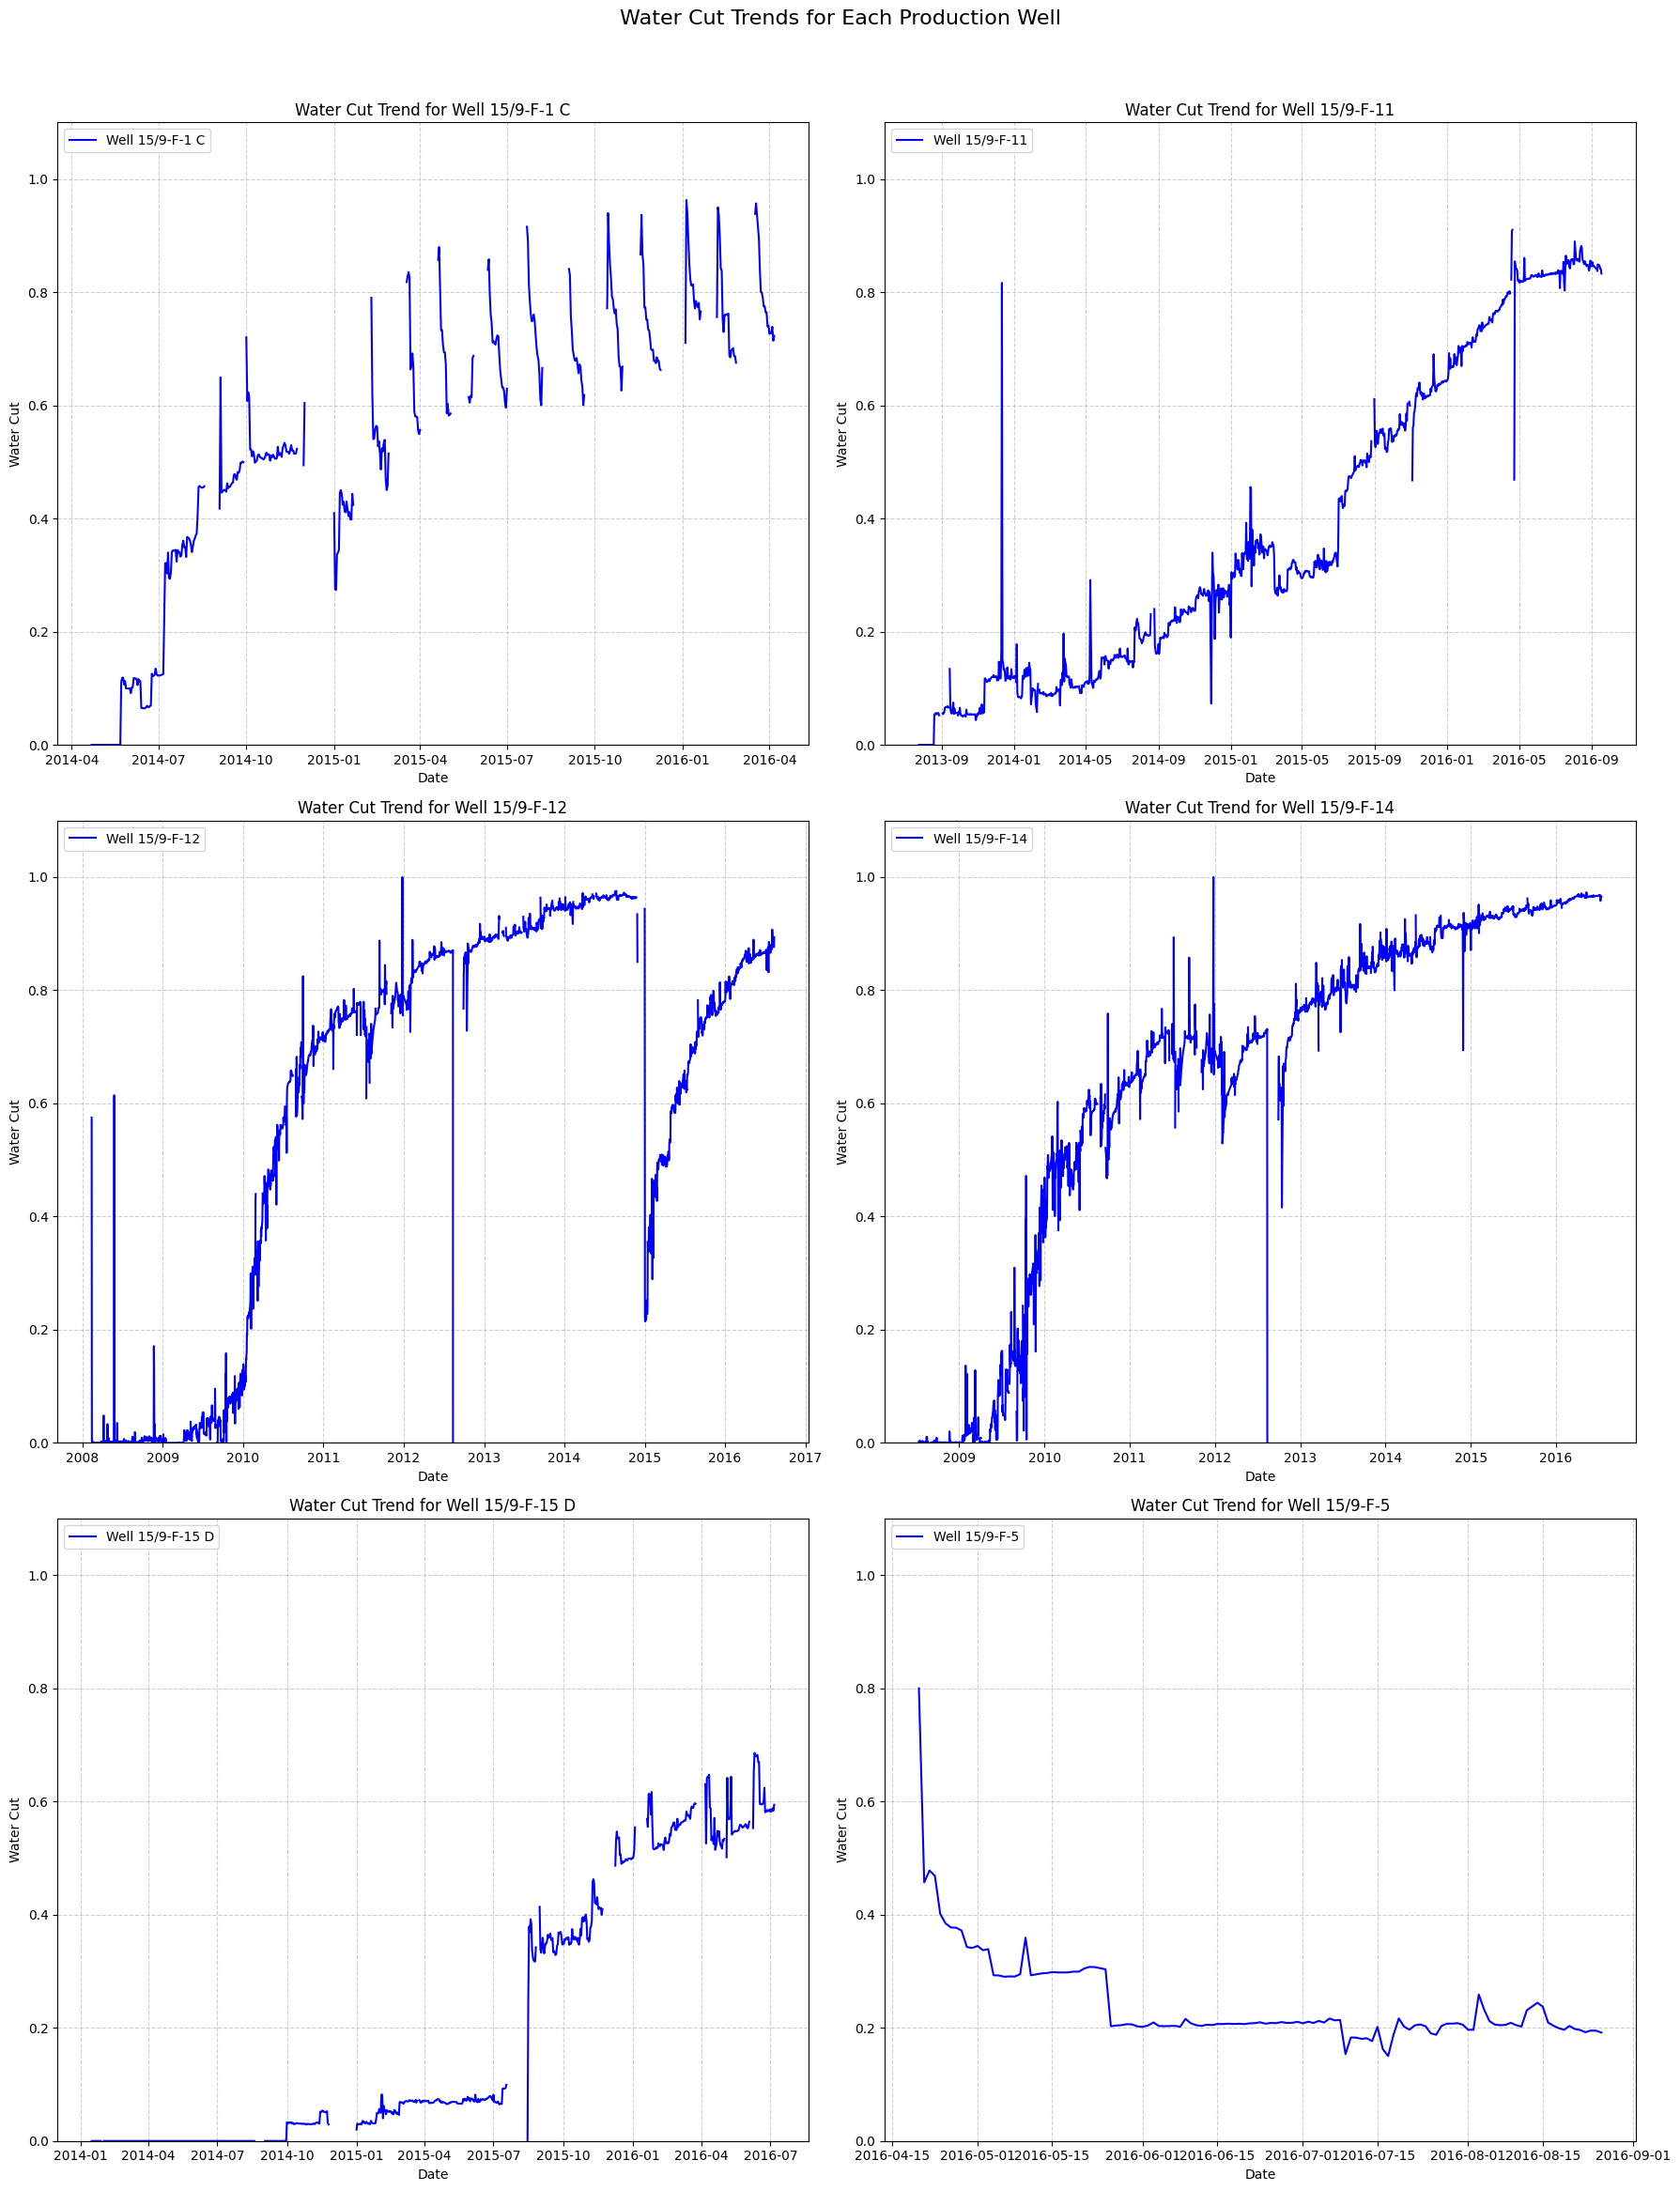

In [35]:

production_df = volve[volve['FLOW_KIND'] == 'production'].copy()

# Fill NaN production volumes with 0 for accurate water cut calculation
production_df['BORE_OIL_VOL'] = production_df['BORE_OIL_VOL'].fillna(0)
production_df['BORE_WAT_VOL'] = production_df['BORE_WAT_VOL'].fillna(0)

# Calculate Water Cut (WC = BORE_WAT_VOL / (BORE_OIL_VOL + BORE_WAT_VOL))
# Handle division by zero and cases where no fluids are produced.
production_df['Total_Fluid_Volume'] = production_df['BORE_OIL_VOL'] + production_df['BORE_WAT_VOL']

def calculate_water_cut(row):
    if row['Total_Fluid_Volume'] > 0:
        return row['BORE_WAT_VOL'] / row['Total_Fluid_Volume']
    else:
        return np.nan # Water cut is undefined if no fluids are produced

production_df['WATER_CUT'] = production_df.apply(calculate_water_cut, axis=1)

# Get unique production well bore codes
production_well_codes = production_df['NPD_WELL_BORE_NAME'].unique()

plt.figure(figsize=(18, len(production_well_codes) * 4))
num_wells = len(production_well_codes)
num_cols = 2
num_rows = (num_wells + num_cols - 1) // num_cols

for i, well in enumerate(production_well_codes):
    well_data = production_df[production_df['NPD_WELL_BORE_NAME'] == well].copy()
    well_data = well_data.sort_index()

    plt.subplot(num_rows, num_cols, i + 1)
    plt.plot(well_data.index, well_data['WATER_CUT'], label=f'Well {well}', color='blue') # Use well_data.index for plotting dates
    plt.title(f'Water Cut Trend for Well {well}', fontsize=12)
    plt.xlabel('Date', fontsize=10)
    plt.ylabel('Water Cut', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper left')
    plt.ylim(0, 1.1) # Water cut ranges from 0 to 1

plt.suptitle('Water Cut Trends for Each Production Well', y=1.00, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()


Analysis of Water Cut Trends:
-----------------------------
Upon analyzing the water cut trends for each production well, we can observe the following:

1. **Initial Period of Low/Zero Water Cut:** Most wells, especially at the beginning of their production life, show a period of very low or zero water cut. This is expected as oil production typically starts with little to no water.

2. **Onset of Water Cut Climb:**
   - **15/9-F-1 C, 15/9-F-11, 15/9-F-12, 15/9-F-14:** These wells show a noticeable increase in water cut, typically starting several months to a year or more after initial production. The climb usually correlates with the onset of oil production decline, indicating water breakthrough in the reservoir.
   - **15/9-F-15 D:** This well shows water cut increasing more rapidly and reaching high levels relatively early in its production life, suggesting early water breakthrough or a different reservoir characteristic.
   - **15/9-F-5:** This well has intermittent and generally low production, and its water cut trend is less clear or stable, often fluctuating without a consistent climb.

3. **Shape of the Climb:**
   - **Gradual vs. Steep:** The climb in water cut is generally **gradual** for many wells (e.g., 15/9-F-1 C, 15/9-F-12, 15/9-F-14), showing a relatively smooth increase over time. However, for wells like **15/9-F-15 D**, the climb can be **steeper** or more abrupt, reaching high water cuts quickly.
   - **Plateau/Fluctuation at High Water Cut:** Once water cut reaches high levels (e.g., above 0.8 or 0.9), it often tends to plateau or fluctuate at these high values, as the well primarily produces water with diminishing amounts of oil.

4. **Consistency Across Wells:** While all production wells (that produce oil) eventually experience an increase in water cut, **the shape and timing of the climb are not exactly the same across all wells**. Differences can be attributed to various factors such as well placement, reservoir heterogeneity, water injection strategies, and operational changes. Some wells show a more classic S-shaped curve (slow start, rapid increase, then plateau), while others might have more erratic or rapid increases.